# ECON3203 Group Project: Sensational

## Explore & Prepare data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# load data
sample_url="https://drive.google.com/uc?export=download&id=1ekCjJOTjGD0OASErwVnwhJuPD0hFfCEF"
out_url=sample_url
db_sample = pd.read_csv(sample_url)
db_out = pd.read_csv(out_url)

In [3]:
db_sample.head()

,score_read,score_math,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
0,474.0,602.0,male,1980 Q2,free,cauc,small,rural,master,level1,6.0,cauc,36.0,72.0
1,403.0,434.0,male,1980 Q3,free,afam,small,rural,bachelor,apprentice,1.0,cauc,24.0,57.0
2,455.0,520.0,male,1980 Q2,non-free,cauc,regular+aide,suburban,bachelor,level1,5.0,afam,22.0,51.0
3,405.0,454.0,female,1979 Q4,free,cauc,regular+aide,rural,bachelor,level1,11.0,cauc,4.0,6.0
4,433.0,473.0,female,1980 Q3,non-free,cauc,regular,rural,bachelor,level1,2.0,cauc,40.0,76.0


In [4]:
# Simple data stats
db_sample.describe(include="all")

,score_read,score_math,gender,birth,lunch,ethnicity,class_type,school,degree,ladder,experience,t_ethnicity,schooldistrict_id,school_id
count,4643.000000,4706.000000,5060,5055,5039,5059,5060,5060,5041,4549,5041.000000,5008,5060.000000,5060.000000
unique,NaN,NaN,2,15,2,6,3,4,4,5,NaN,2,NaN,NaN
top,NaN,NaN,male,1980 Q3,non-free,cauc,regular+aide,rural,bachelor,level1,NaN,cauc,NaN,NaN
freq,NaN,NaN,2591,1333,2578,3389,1786,2351,3306,3737,NaN,4193,NaN,NaN
mean,436.272238,485.123459,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.277723,NaN,18.699209,40.042885
std,31.358938,47.674836,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.854946,NaN,11.046311,22.770969
min,346.000000,288.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,1.000000,1.000000
25%,414.000000,454.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.000000,NaN,11.000000,21.000000
50%,433.000000,478.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.000000,NaN,15.000000,39.000000
75%,453.000000,513.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13.000000,NaN,27.000000,60.000000


- count → number of valid (non-missing) values
- unique → number of distinct categories (categorical data only)
- top → modal (most common) category
- freq → how often that top category appears


In [5]:
# Categorical exploration
categorical_cols = db_sample.select_dtypes(include='object').columns

for col in categorical_cols:
    print(db_sample[col].value_counts(),"\n")


gender
male      2591
female    2469
Name: count, dtype: int64 

birth
1980 Q3    1333
1980 Q1    1232
1980 Q2    1222
1979 Q4     901
1979 Q3     160
1979 Q2      69
1980 Q4      53
1979 Q1      43
1978 Q4      29
1978 Q2       4
1981 Q1       2
1978 Q3       2
1981 Q4       2
1978 Q1       2
1981 Q3       1
Name: count, dtype: int64 

lunch
non-free    2578
free        2461
Name: count, dtype: int64 

ethnicity
cauc        3389
afam        1646
asian         11
other          6
hispanic       5
amindian       2
Name: count, dtype: int64 

class_type
regular+aide    1786
regular         1761
small           1513
Name: count, dtype: int64 

school
rural         2351
inner-city    1134
suburban      1123
urban          452
Name: count, dtype: int64 

degree
bachelor      3306
master        1581
master+        121
specialist      33
Name: count, dtype: int64 

ladder
level1        3737
apprentice     413
probation      261
level2          97
level3          41
Name: count, dtype: int64 


#### Dealing with Missing values
Exploring data to see if missing values are random or not.

In [6]:
# Count missing values and calculate missing rate per column
missing_counts = db_sample.isnull().sum()
missing_rate = db_sample.isnull().mean()

# Combine into a summary DataFrame
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Rate (%)': (missing_rate * 100).round(2)
})
# Count rows with at least one missing value
num_missing_rows = db_sample.isnull().any(axis=1).sum()

# Display
print(f"Missing Value Summary: {num_missing_rows} ({(num_missing_rows/len(db_sample)*100).round(2)}%) unique missing rows")
missing_summary

Missing Value Summary: 903 (17.85%) unique missing rows


,Missing Count,Missing Rate (%)
score_read,417,8.24
score_math,354,7.00
gender,0,0.00
birth,5,0.10
lunch,21,0.42
ethnicity,1,0.02
class_type,0,0.00
school,0,0.00
degree,19,0.38
ladder,511,10.10


In [7]:
#Prints missing-rate of a variable grouped by another variable.
def missing_rate(df, var, group_by):

    # Calculate missingness rate
    missing_rate = df[var].isna().groupby(df[group_by]).mean()

    # Filter to show only groups with missing values
    missing_groups = missing_rate[missing_rate > 0]

    # Print result
    print(f"\nMissing rate for '{var}' grouped by '{group_by}': {len(missing_groups)} missing")
    print(missing_groups.round(4))

missing_rate(db_sample, "score_read", "school")
missing_rate(db_sample, "score_math", "school")
missing_rate(db_sample, "ladder", "school")
missing_rate(db_sample, "ladder", "school_id")
missing_rate(db_sample, "ladder", "schooldistrict_id")
missing_rate(db_sample, "lunch", "school")
missing_rate(db_sample, "lunch", "schooldistrict_id")
missing_rate(db_sample, "experience", "school_id")
missing_rate(db_sample, "experience", "schooldistrict_id")
missing_rate(db_sample, "t_ethnicity", "schooldistrict_id")
missing_rate(db_sample, "t_ethnicity", "school_id")



Missing rate for 'score_read' grouped by 'school': 4 missing
school
inner-city    0.0961
rural         0.0638
suburban      0.1104
urban         0.0752
Name: score_read, dtype: float64

Missing rate for 'score_math' grouped by 'school': 4 missing
school
inner-city    0.0855
rural         0.0595
suburban      0.0784
urban         0.0642
Name: score_math, dtype: float64

Missing rate for 'ladder' grouped by 'school': 4 missing
school
inner-city    0.1323
rural         0.0515
suburban      0.1781
urban         0.0885
Name: ladder, dtype: float64

Missing rate for 'ladder' grouped by 'school_id': 24 missing
school_id
1.0     0.5424
4.0     0.2353
17.0    0.1875
18.0    0.2817
20.0    0.5246
25.0    0.7407
27.0    0.1707
28.0    0.2833
32.0    0.5579
33.0    0.0952
34.0    0.2321
35.0    0.3704
37.0    0.2593
42.0    0.2295
43.0    0.4746
44.0    0.4789
45.0    0.3111
47.0    0.2245
48.0    0.2317
50.0    0.2059
51.0    0.1121
58.0    0.2051
71.0    0.3333
73.0    0.1754
Name: ladder, dtyp

- 19 rows of missing teacher experience is not random, only in school_id = 48 or school_district = 20 missing 23% of this variable among their groups. Those schools are in urban (4% missing), class_type is regular_aide (1%), ethnicity is cauc (0.56%).
- 21 rows of lunch missing feel like random, spread among school districtid

-> Drop 19 missing rows of experience

-> Drop 21 missing rows of lunch
- 511 rows of missing ladder potentially not random, 54% of the missing ladder is in school_id=1 or school_district=1.

-> Label the missing rows in ladder and clasified as 'Missing' as the amount of missing rows is quite huge

- t_etchnicity is not random only missing in schooldistrict_id=23, school_id=55, missing 27% of the data

-> Drop 52 rows of t_etnicity

In [8]:
# Function for general cleaning, applicable to both frames
def data_cleaner(db_sample):
  # Drop missing rows in experience, lunch and t_ethnicity
  cleaned_data = db_sample.dropna(subset=["experience", "lunch", "t_ethnicity"])

  # Drop these columns due to multi-collinearity and unneccessary
  cleaned_data = cleaned_data.drop(["birth", "schooldistrict_id", "school_id"], axis=1)
  # Fill in missing values in ladder with new label 'Missing'
  cleaned_data["ladder"] = cleaned_data["ladder"].fillna("Missing")

  return cleaned_data

cleaned_data = data_cleaner(db_sample)
cleaned_data.describe()

# Function to create searate frames for read and math scores.
def create_frames(db_sample: pd.DataFrame):
    ladder_map = {
        "probation": "1probation",
        "apprentice": "2apprentice",
        "level1": "3level1",
        "level2": "4level2",
        "level3": "5level3"
    }

    db_sample["ladder"] = db_sample["ladder"].replace(ladder_map)
    # creating copies for both read and math scores
    math = db_sample.copy()
    math = math.drop("score_read", axis=1)
    math = math.dropna(subset="score_math")
    read = db_sample.copy()
    read = read.drop("score_math", axis=1)
    read = read.dropna(subset="score_read")

    return read, math

read, math = create_frames(cleaned_data)

blue = "#4C72B0"
green = "#55A868"


the data frame `read` keeps 4593 rows from 4643 rows even after dropping rows with missing values in `experience`, `t_ethnicity` and `lunch`, losing about 50 rows in total, only 0.01% of data.

Similarly, in the data frame `math` 4656 rows remain from 4706 rows, similarly losing only about 50 rows, about 0.01% of data.

#### Exploring data correlation.



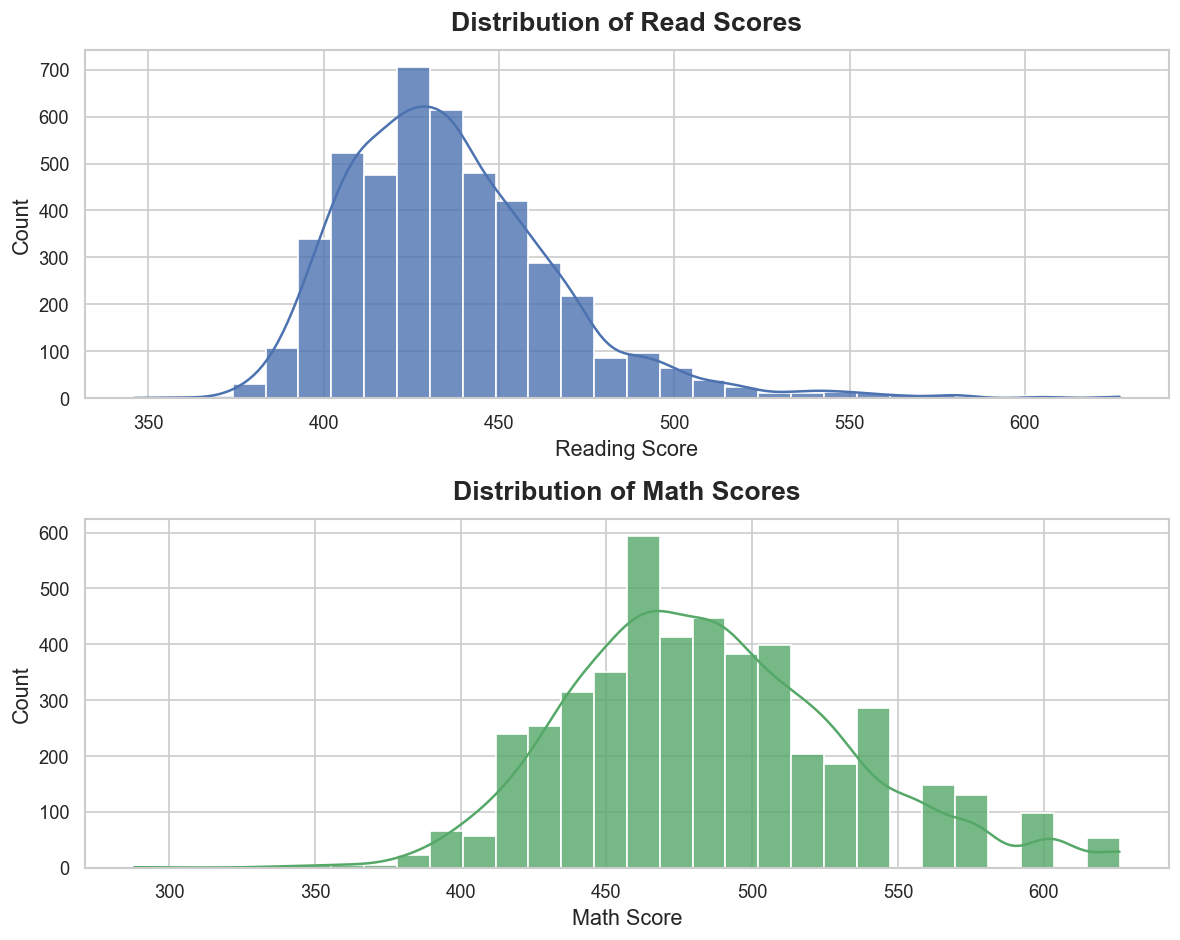

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 8), dpi=120)

# --- Reading Score ---
plt.subplot(2, 1, 1)
sns.histplot(read['score_read'], kde=True, color=blue, alpha=0.8, bins=30)
plt.title("Distribution of Read Scores", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Reading Score", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

# --- Math Score ---
plt.subplot(2, 1, 2)
sns.histplot(math['score_math'], kde=True, color=green, alpha=0.8, bins=30)
plt.title("Distribution of Math Scores", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Math Score", fontsize=13)
plt.ylabel("Count", fontsize=13)
plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()


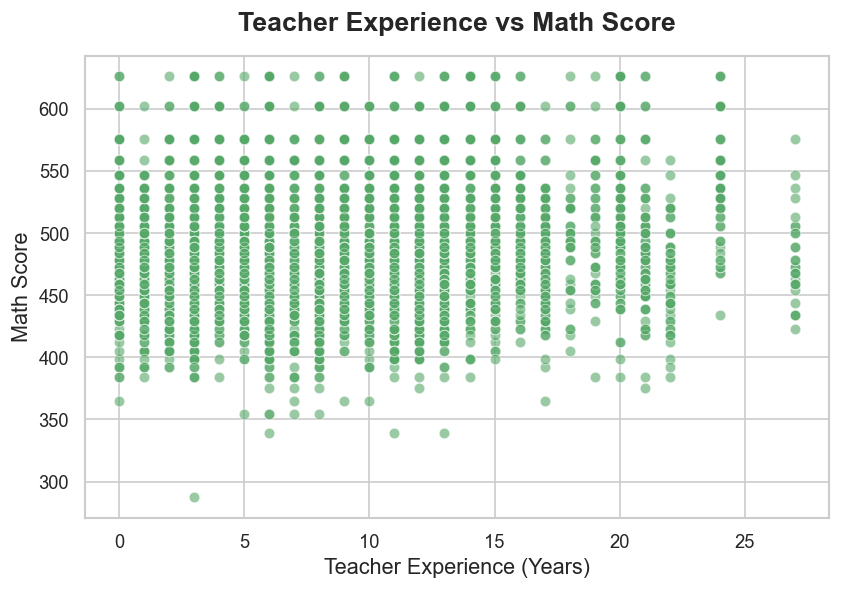

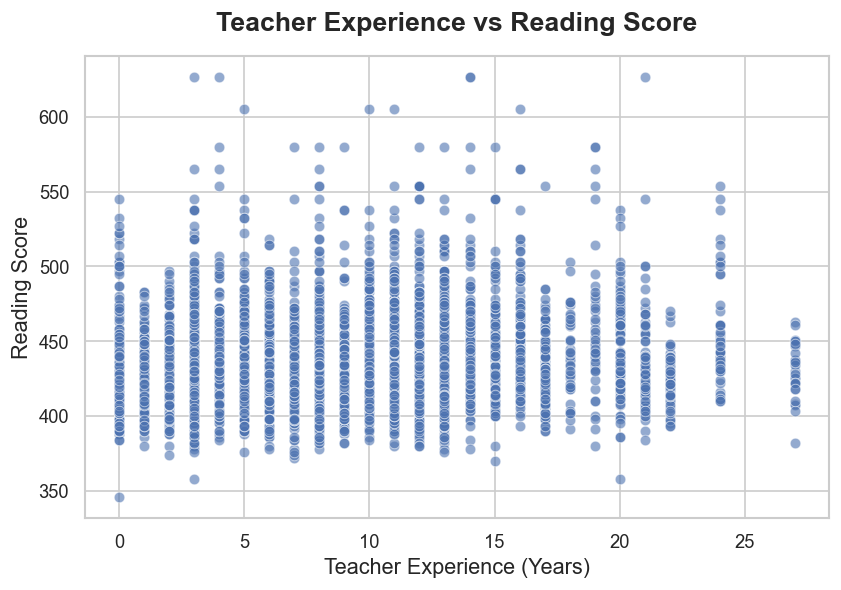

Correlation (Experience vs Math):
             experience  score_math
experience     1.00000     0.10425
score_math     0.10425     1.00000

Correlation (Experience vs Reading):
             experience  score_read
experience     1.00000     0.11652
score_read     0.11652     1.00000


In [10]:
plt.figure(figsize=(8, 5), dpi=120)

sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=math,
    x="experience",
    y="score_math",
    alpha=0.6,
    s=40,
    color=green
)

plt.title("Teacher Experience vs Math Score", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Teacher Experience (Years)", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()

plt.figure(figsize=(8, 5), dpi=120)

sns.set_theme(style="whitegrid")

sns.scatterplot(
    data=read,
    x="experience",
    y="score_read",
    alpha=0.6,
    s=40,
    color=blue
)

plt.title("Teacher Experience vs Reading Score", fontsize=16, fontweight="bold", pad=15)
plt.xlabel("Teacher Experience (Years)", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.show()


# Print correlations
print("Correlation (Experience vs Math):\n", math[["experience", "score_math"]].corr())
print("\nCorrelation (Experience vs Reading):\n", read[["experience", "score_read"]].corr())


It is evident from the correlation coefficient that there is a very limited effect on teacher experience on math and read scores. However, we may still use `experience` depending on how important regression models such as lasso and ridge seem to think the predictor is.

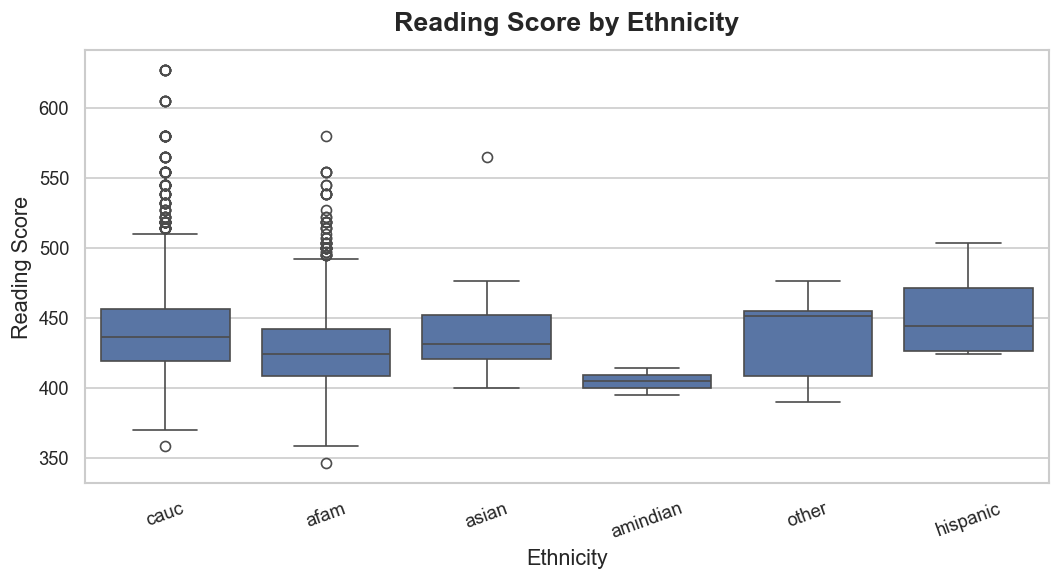

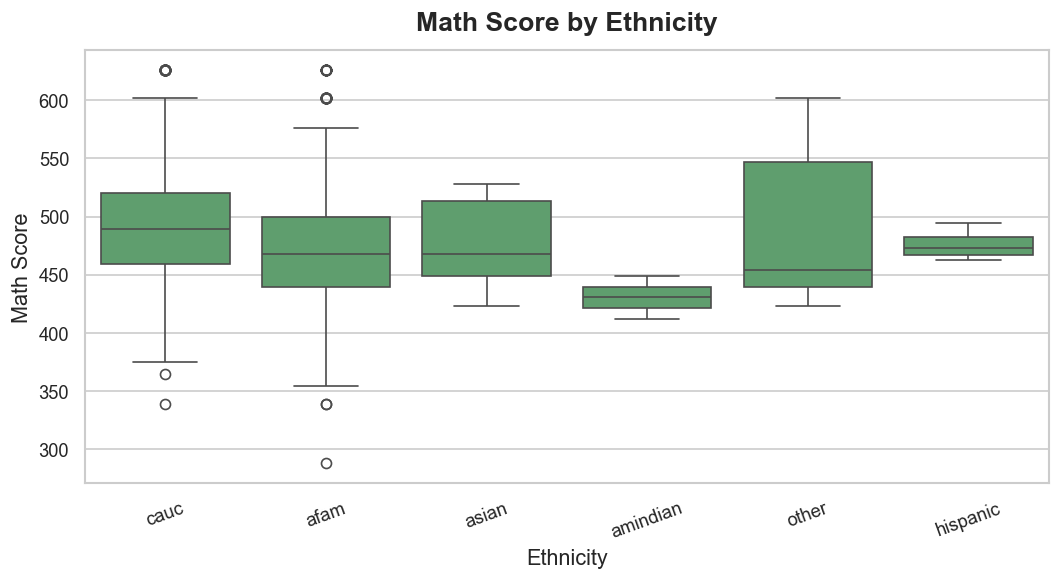

In [11]:
# Plotting scores against student ethnicity
# Read scores
sns.set_theme(style="whitegrid")

plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=read, x='ethnicity', y='score_read', color=blue)
plt.title("Reading Score by Ethnicity", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Ethnicity", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)
plt.xticks(fontsize=11, rotation=20)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

# Math scores

plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=math, x='ethnicity', y='score_math', color=green)
plt.title("Math Score by Ethnicity", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Ethnicity", fontsize=13)
plt.ylabel("Math Score", fontsize=13)
plt.xticks(fontsize=11, rotation=20)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()


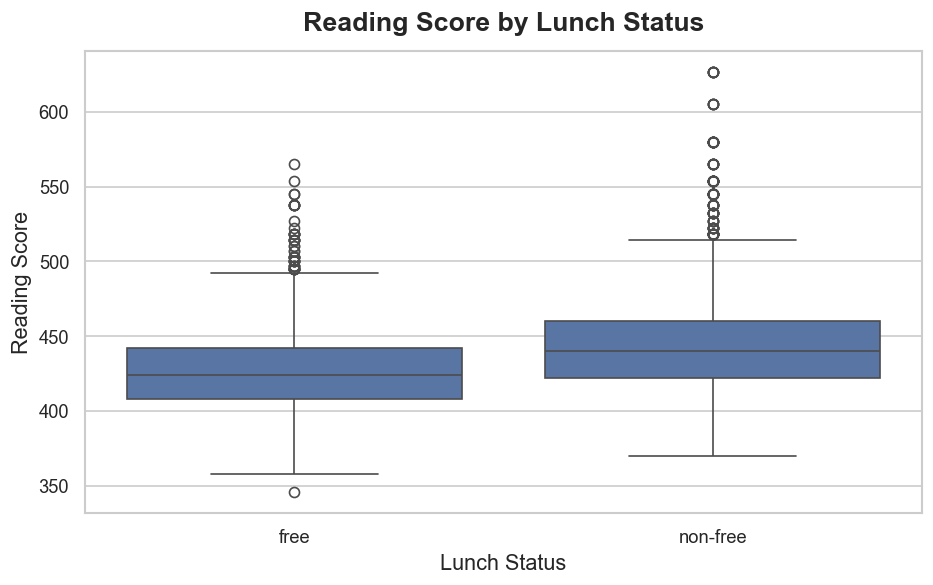

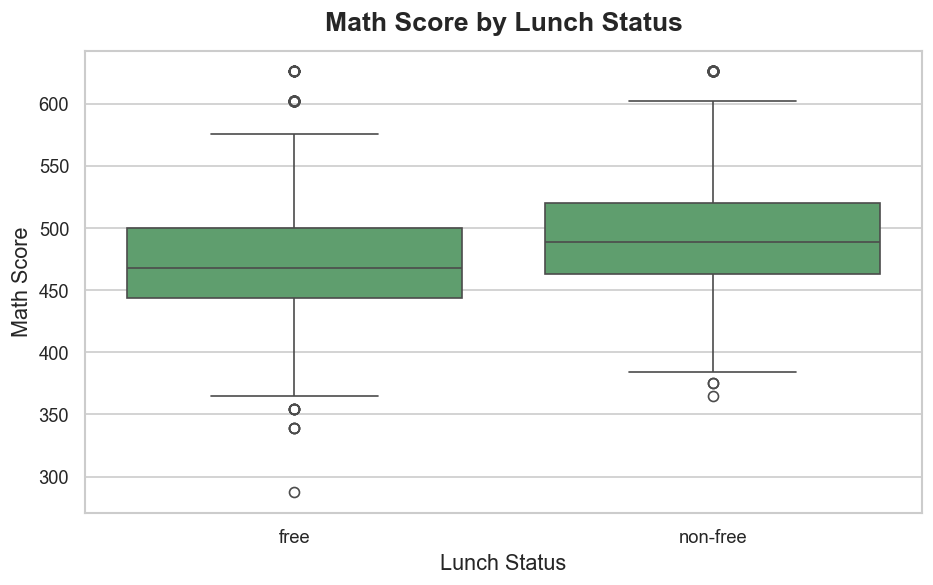

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")   # modern, clean

# ---- Reading Score by Lunch ----
plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=read, x='lunch', y='score_read', color=blue)

plt.title("Reading Score by Lunch Status", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Lunch Status", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# ---- Math Score by Lunch ----
plt.figure(figsize=(9, 5), dpi=120)
sns.boxplot(data=math, x='lunch', y='score_math', color=green)

plt.title("Math Score by Lunch Status", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Lunch Status", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


It looks like schools with free lunches tend to perform slightly worse than those that did not. It is possible that the reason for this is that Schools providing free lunches are located in areas where socio-economic factors are detrimental to student performance. As such, we may use `lunch` as a predictor to determine how well off a student is.

It seems as though both read and math scores are lower for american indian students. Similar to the `lunch` predictor, a student of American Indian descent may have worse socio-economic factors assosciatied with them. `ethnicity` may be one hot encoded to denote if a student is American Indian or not.

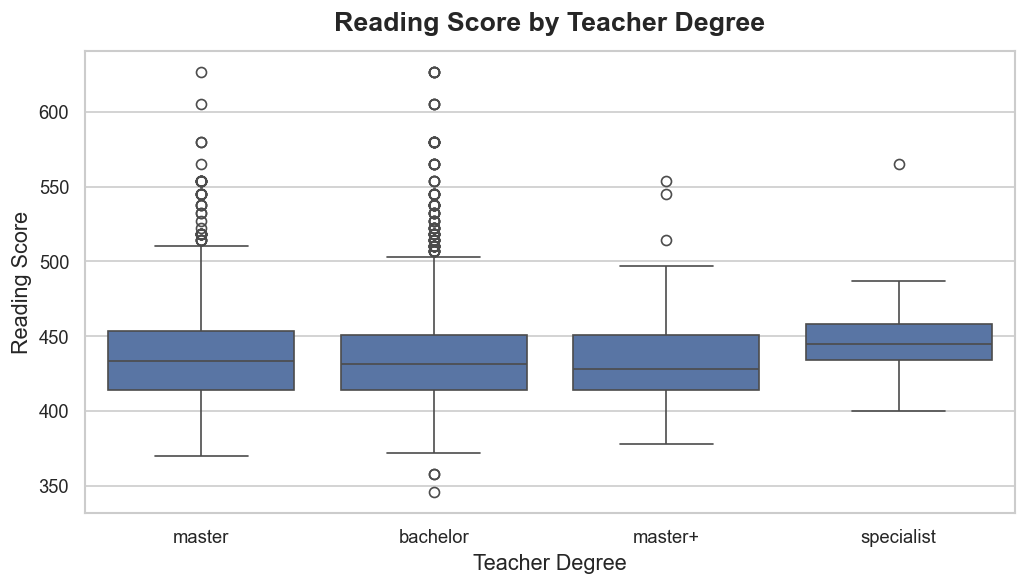

In [13]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='degree', y='score_read', color=blue)

plt.title("Reading Score by Teacher Degree", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Degree", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()



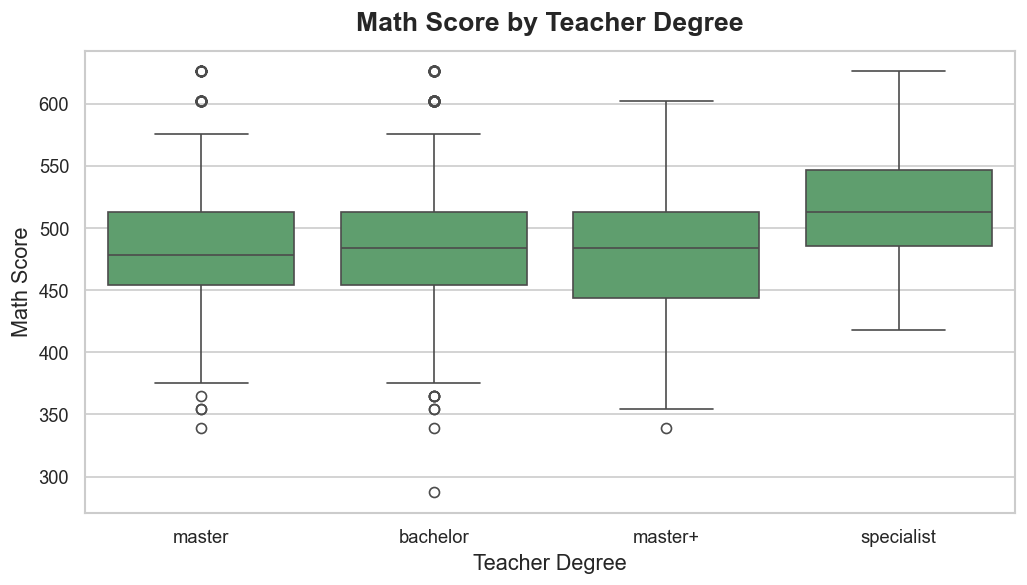

In [14]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='degree', y='score_math', color=green)

plt.title("Math Score by Teacher Degree", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Degree", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


Teachers with specialist degrees seem to have a stronger influence on students' scores in both fields. This may be because specialist teachers are more accessible to schools that are “richer,” and it could also reflect a combination of higher teacher quality and a better overall student environment.


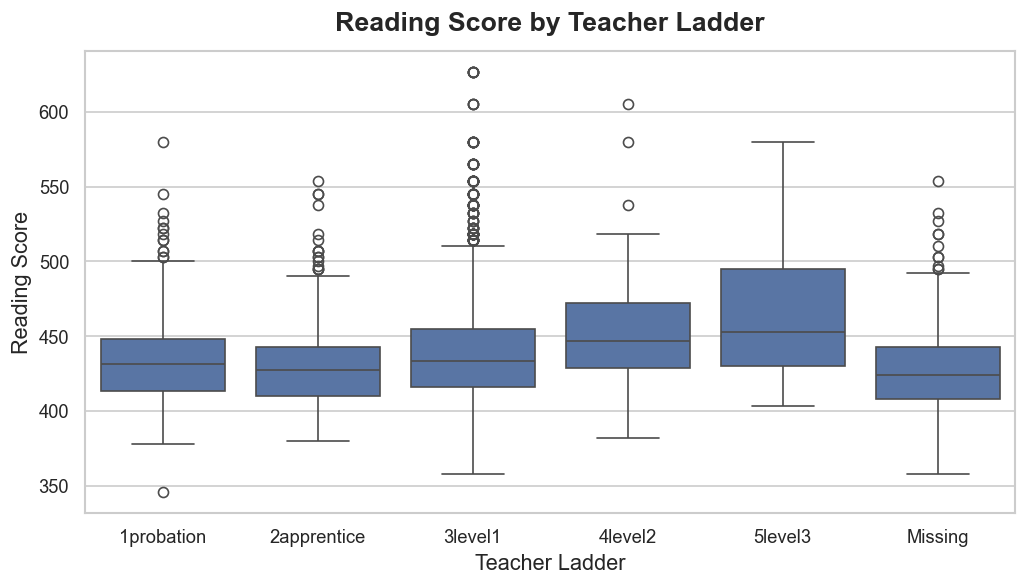

In [15]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(
    data=read.sort_values(by="ladder"),
    x='ladder',
    y='score_read',
    color=blue
)

plt.title("Reading Score by Teacher Ladder", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Teacher Ladder", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()




Apprentice->Probation->level1->level2->level3 : slight better performance for both fields as the teacher career ladder increases. As `ladder` is also a type of measure of teacher experience, the predictor `experience` may be dropped.


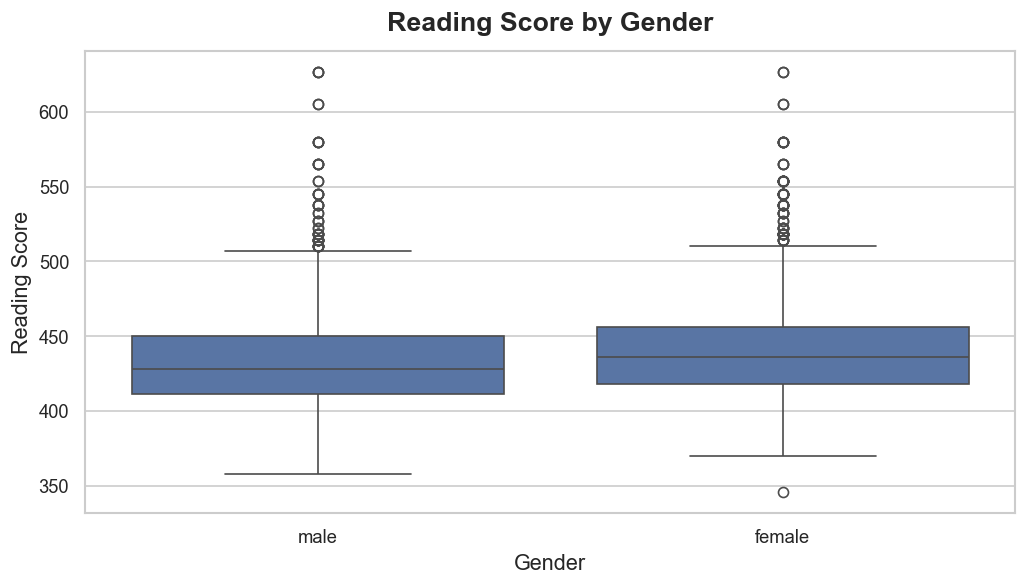

In [16]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='gender', y='score_read', color=blue)

plt.title("Reading Score by Gender", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Reading Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


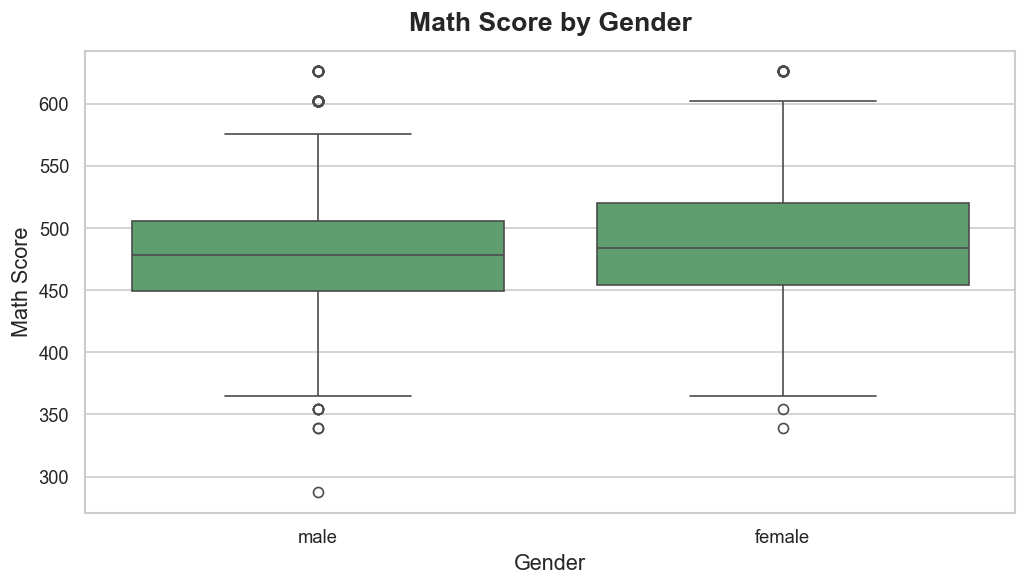

In [17]:
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='gender', y='score_math', color=green)

plt.title("Math Score by Gender", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Gender", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()


It is unlikely that student `gender` influences read or math scores to a significant extent, but it seems that there is a slightly higher score in both of those categories for students that were female.

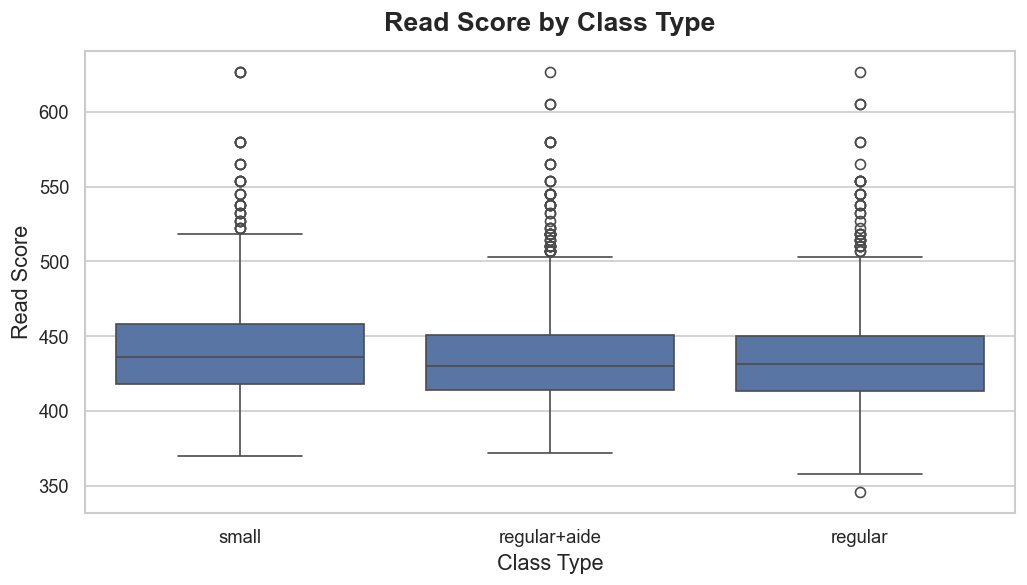

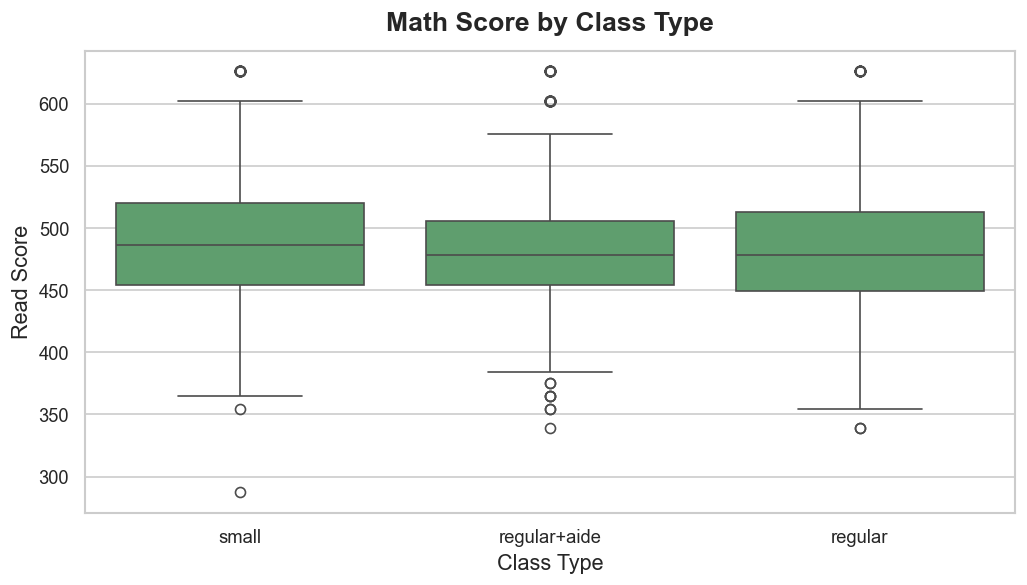

In [18]:
# Read
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='class_type', y='score_read', color=blue)

plt.title("Read Score by Class Type", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Class Type", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# MATH

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='class_type', y='score_math', color=green)

plt.title("Math Score by Class Type", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("Class Type", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

It seems like the median and third quartile values for small classrooms are cleary above both regular classrooms. Could be that smaller class size leads to more individual focus leading to higher test scores.


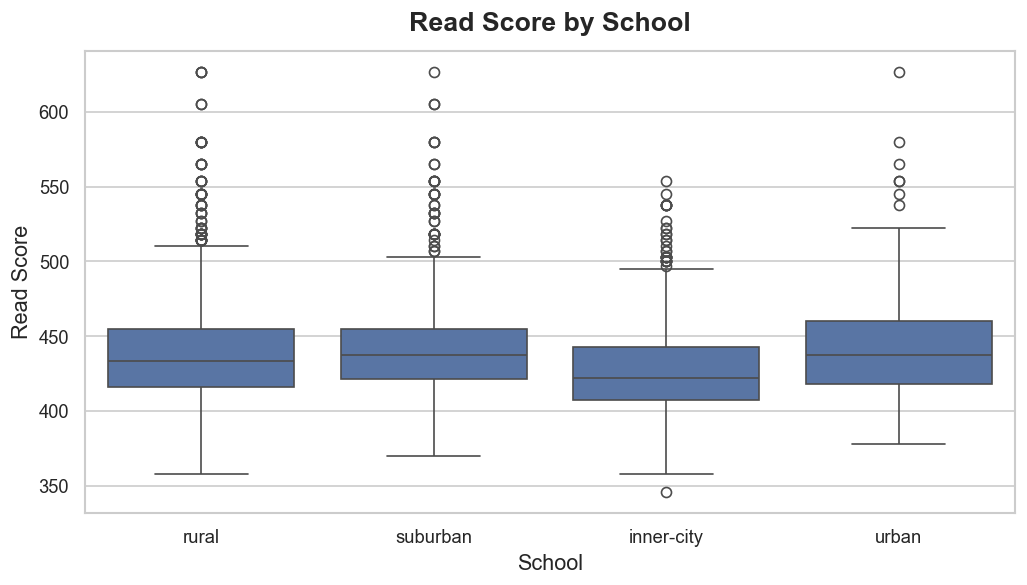

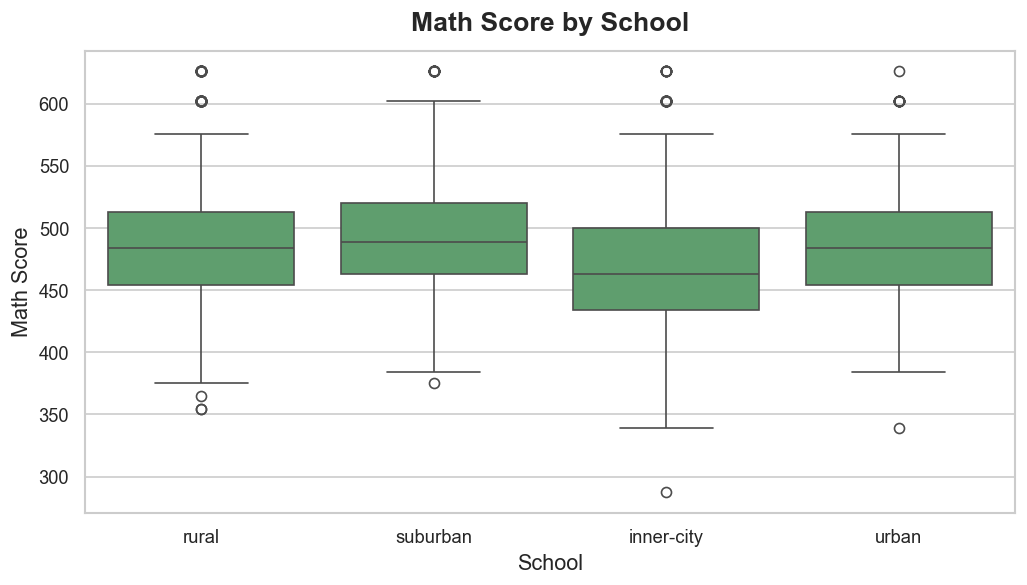

In [19]:
# Read
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=read, x='school', y='score_read', color=blue)

plt.title("Read Score by School", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("School", fontsize=13)
plt.ylabel("Read Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

# Math
plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=math, x='school', y='score_math', color=green)

plt.title("Math Score by School", fontsize=16, fontweight='bold', pad=12)
plt.xlabel("School", fontsize=13)
plt.ylabel("Math Score", fontsize=13)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)
plt.show()

Suburban and urban schools show slightly higher reading and math scores, while inner-city schools have the lowest medians. Overall differences are small.

## Modeling score_read

In [20]:
from itertools import combinations
# Include interaction term
def create_interactions(df,columns):
    # Select only numerical columns
    df_subset = df[columns].copy()

    # Create interaction terms
    interaction_df = df_subset.copy()
    for col1, col2 in combinations(columns, 2):
        interaction_name = f"{col1}_x_{col2}"
        interaction_df[interaction_name] = df[col1] * df[col2]

    return interaction_df

In [21]:
# Drop missing values of score_read
db_read = read

In [22]:
# Make catagorical vars into dummy vars
db_read=pd.get_dummies(db_read, drop_first=True)
db_read.rename(columns={'lunch_non-free': 'lunch_nonfree'}, inplace=True)
db_read.rename(columns={'class_type_regular+aide': 'class_type_regular_aide'}, inplace=True)
db_read.rename(columns={'degree_master+': 'degree_masterplus'}, inplace=True)
db_read.describe(include="all")

,score_read,experience,gender_male,lunch_nonfree,ethnicity_amindian,ethnicity_asian,ethnicity_cauc,ethnicity_hispanic,ethnicity_other,class_type_regular_aide,...,school_urban,degree_master,degree_masterplus,degree_specialist,ladder_2apprentice,ladder_3level1,ladder_4level2,ladder_5level3,ladder_Missing,t_ethnicity_cauc
count,4593.000000,4593.000000,4593,4593,4593,4593,4593,4593,4593,4593,...,4593,4593,4593,4593,4593,4593,4593,4593,4593,4593
unique,NaN,NaN,2,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,True,True,False,False,True,False,False,False,...,False,False,False,False,False,True,False,False,False,True
freq,NaN,NaN,2354,2354,4591,4582,3086,4589,4588,2979,...,4196,3121,4482,4563,4211,3430,4503,4552,4162,3875
mean,436.348792,9.314827,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,31.442945,5.824987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,346.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,414.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,433.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,453.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
# Create interaction col
selected_cols = ['experience', 'gender_male', 'lunch_nonfree', 'school_urban','school_suburban','school_rural',
                 'degree_master', 'degree_specialist','ladder_2apprentice','ladder_3level1',
                 'ladder_4level2','ladder_5level3','t_ethnicity_cauc','class_type_small']
interactions = create_interactions(db_read,selected_cols)
interactions = interactions.drop(columns=[col for col in interactions.columns if col in db_read.columns])
db_read = pd.concat([db_read, interactions], axis=1)


### OLS of score_read

In [24]:
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.formula.api import ols


In [25]:
# Define X and y
X = db_read.drop(columns=['score_read'])
y = db_read['score_read']

In [26]:

# Ensure unique column names in the formula
formula = f'score_read ~ {" + ".join(X.columns.unique())}'
print(formula)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit OLS model full
OLSmodel = ols(formula, data=pd.concat([X_train, y_train], axis =1)).fit()

# Predict and evaluate
y_pred = OLSmodel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Print summary and MSE
print(OLSmodel.summary())
print(f"MSE: {mse}")

score_read ~ experience + gender_male + lunch_nonfree + ethnicity_amindian + ethnicity_asian + ethnicity_cauc + ethnicity_hispanic + ethnicity_other + class_type_regular_aide + class_type_small + school_rural + school_suburban + school_urban + degree_master + degree_masterplus + degree_specialist + ladder_2apprentice + ladder_3level1 + ladder_4level2 + ladder_5level3 + ladder_Missing + t_ethnicity_cauc + experience_x_gender_male + experience_x_lunch_nonfree + experience_x_school_urban + experience_x_school_suburban + experience_x_school_rural + experience_x_degree_master + experience_x_degree_specialist + experience_x_ladder_2apprentice + experience_x_ladder_3level1 + experience_x_ladder_4level2 + experience_x_ladder_5level3 + experience_x_t_ethnicity_cauc + experience_x_class_type_small + gender_male_x_lunch_nonfree + gender_male_x_school_urban + gender_male_x_school_suburban + gender_male_x_school_rural + gender_male_x_degree_master + gender_male_x_degree_specialist + gender_male_x_l

### Lasso,Ridge, and ElasticNet

In [27]:
# Lasso for score_read
train, test = train_test_split(db_read, test_size = 0.3,random_state=1)
response = 'score_read'
numerical_predictors = ['experience','experience_x_gender_male','experience_x_lunch_nonfree','experience_x_school_urban',
                        'experience_x_school_suburban','experience_x_school_rural','experience_x_degree_master',
                        'experience_x_degree_specialist','experience_x_ladder_2apprentice',
                        'experience_x_ladder_3level1','experience_x_ladder_4level2','experience_x_ladder_5level3','experience_x_t_ethnicity_cauc']
predictors = [x for x in db_read.columns if x not in response] # the list of all predictors
mu = train[numerical_predictors].mean() # mean for each feature
sigma = train[numerical_predictors].std() # std for each feature

In [28]:
train_std = train.copy()
test_std = test.copy()
train_std[numerical_predictors] = (train[numerical_predictors] - mu) / sigma
test_std[numerical_predictors] = (test[numerical_predictors] - mu) / sigma

train_std[numerical_predictors].mean()
train_std[numerical_predictors].std()

experience                         1.0
experience_x_gender_male           1.0
experience_x_lunch_nonfree         1.0
experience_x_school_urban          1.0
experience_x_school_suburban       1.0
experience_x_school_rural          1.0
experience_x_degree_master         1.0
experience_x_degree_specialist     1.0
experience_x_ladder_2apprentice    1.0
experience_x_ladder_3level1        1.0
experience_x_ladder_4level2        1.0
experience_x_ladder_5level3        1.0
experience_x_t_ethnicity_cauc      1.0
dtype: float64

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 2, 100)
lasso_cv = LassoCV(alphas=alphas,cv = 5) #5-fold CV - returns optimal lambda as part of the process
lasso_cv.fit(train_std[predictors],train_std[response])
print(f'LASSO Lambda: {lasso_cv.alpha_}')
# Lasso MSE
y_pred_test = lasso_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

LASSO Lambda: 0.020565123083486514
Test R²:  0.1667
Test MSE:  855.22


In [30]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 2, 100) # grid is on log scale 100 values from 10^-3 to 10^2
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(train_std[predictors], train_std[response])
print(f'Ridge Lambda: {ridge_cv.alpha_}')
# Ridge mse

y_pred_test = ridge_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")


Ridge Lambda: 8.697490026177835
Test R²:  0.1688
Test MSE:  852.96


In [31]:
from sklearn.linear_model import ElasticNetCV
l1_ratio_grid = [0.001, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
alphas = np.logspace(-3, 2, 100)
enet_cv = ElasticNetCV(alphas=alphas,l1_ratio = l1_ratio_grid, cv = 5, random_state=42) #alphas grid is determined by default 100 values on log scale as in LASSO
enet_cv.fit(train_std[predictors],train_std[response])
print(f'ElasticNet Lambda: {enet_cv.alpha_} l1_ratio: {enet_cv.l1_ratio_}')
# elasticNet MSE
y_pred_test = enet_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.131e+02, tolerance: 2.510e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.714e+02, tolerance: 2.499e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

ElasticNet Lambda: 0.011497569953977356 l1_ratio: 0.8
Test R²:  0.1677
Test MSE:  854.09


In [32]:
# Summarize of OLS,lasso,ridge,elasticnet for score_read
columns = ['R-squared', 'Test MSE']
rows = ['OLS','Ridge','LASSO','Elastic Net']

results = pd.DataFrame(0.0, columns=columns, index=rows) # initialising a dataframe to hold the results

methods = [OLSmodel, ridge_cv, lasso_cv, enet_cv]
test_data = [X_test, test_std[predictors], test_std[predictors], test_std[predictors]] # Use scaled data for sklearn models

for row, method, test_X in zip(rows, methods, test_data):
    if row == 'OLS':
        # For OLS, predict directly and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
    else:
        # For scikit-learn models, predict from the scaled test data and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(test_std[response], y_pred)
        mse = mean_squared_error(test_std[response], y_pred)

    results.loc[row, 'R-squared'] = r2
    results.loc[row, 'Test MSE'] = mse

results.round(3)

,R-squared,Test MSE
OLS,0.144,873.268
Ridge,0.169,852.963
LASSO,0.167,855.217
Elastic Net,0.168,854.089


Ridge seems to perform the best.

### Xgboost with interactions terms

In [33]:
import xgboost as xgb
import shap

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'min_child_weight':5,
    'learning_rate':0.1,
    'subsample': 0.7,
    'colsample_bytree': 0.5
}
model_xg = xgb.XGBRegressor(early_stopping_rounds=10,
                            verbosity=0,
                            **params)
model_xg.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=False)

y_pred_train = model_xg.predict(X_train)
y_pred_test = model_xg.predict(X_test)

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_test):.2f}")


Train R²: 0.3415
Test R²:  0.1943
Train MSE: 641.82
Test MSE:  822.19


Not bad at all, but let us explore tree models

### Tree regression without Interaction terms

In [34]:
from sklearn.model_selection import GridSearchCV, KFold


In [35]:
# Train tree models without interaction terms
# Create dummy vars
read = pd.get_dummies(read, drop_first=True)
response = 'score_read'
# For cv test (require full data)
X = read.drop(columns=[response])
y = read[response]

train, test = train_test_split(read, test_size = 0.3,random_state=1)

X_train = train.drop(columns=[response])
y_train = train[response]

X_test = test.drop(columns=[response])
y_test = test[response]


#### Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define a metrics function
def metrics(X_test, y_test, model):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return r2, mse

rf = RandomForestRegressor(n_estimators=1000, max_features ='sqrt', min_samples_leaf=4, random_state=1)
rf.fit(X_train, y_train)
ypred_rf = rf.predict(X_test)
# Scores result
r2_rf, mse_rf = metrics(X_test, y_test, rf)

print(f"Test R²:   {r2_rf}")
print(f"Test MSE:  {mse_rf}")

Test R²:   0.2070932654430241
Test MSE:  813.7133153944992


MSE of 813 is much lower than the lasso, ridge and those above models.

In [37]:
rf = RandomForestRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'max_features': ['sqrt', 'log2'],
    "min_samples_leaf": [3,4,5]
    }

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(rf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


{'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 3}


In [38]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")

results.loc['rf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

Fold 1: R² = 0.1430, MSE = 835.8632
Fold 2: R² = 0.1367, MSE = 889.4086
Fold 3: R² = 0.1351, MSE = 856.5915
Fold 4: R² = 0.1574, MSE = 791.5779
Fold 5: R² = 0.1384, MSE = 864.3618

Mean R²: 0.1421
Mean MSE: 847.5606


#### Gradient Boost

In [39]:
from sklearn.ensemble import GradientBoostingRegressor

gbf = GradientBoostingRegressor(n_estimators=1000, n_iter_no_change=50, learning_rate=0.1,
                                subsample=0.7, max_depth=4, random_state=1)
gbf.fit(X_train, y_train)
ypred_gbf = gbf.predict(X_test)
r2_gbf, mse_gbf = metrics(X_test, y_test, gbf)
print(f"Test R²:   {r2_gbf}")
print(f"Test MSE:  {mse_gbf}")


Test R²:   0.21562151851915712
Test MSE:  804.961273341305


Pretty low, but let do CV as this is only one test-train set, high risk of overfitting

In [40]:

gbf = GradientBoostingRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4, 5, 6],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(gbf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

{'learning_rate': 0.02, 'max_depth': 4, 'subsample': 0.6}


In [41]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = GradientBoostingRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['gbf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

Fold 1: R² = 0.2029, MSE = 777.4263
Fold 2: R² = 0.1795, MSE = 845.2993
Fold 3: R² = 0.2013, MSE = 791.0959
Fold 4: R² = 0.2479, MSE = 706.5446
Fold 5: R² = 0.1857, MSE = 816.8859

Mean R²: 0.2035
Mean MSE: 787.4504


MSE of 786 far outperforms everything else we've come across so far.

#### XgBoost

In [42]:
# Xgboost with no interaction terms
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'min_child_weight':5,
    'learning_rate':0.05,
    'subsample': 0.7,
    'colsample_bytree': 0.5
}
xgb_read = xgb.XGBRegressor(n_estimators=1000,
                            verbosity=0,
                            **params,
                            random_state=1)
xgb_read.fit(X_train, y_train,
             verbose=False)
predictions = xgb_read.predict(X_test)
# Predict and evaluate
y_pred = xgb_read.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
#r2_xgb, mse_xgb = metrics(X_test, y_test, xgb)
# Print summary and MSE
print(f"MSE: {mse}")

MSE: 801.3958734965219


This one is based on one test-train data set which has high potemtial of overfitting. The optimize hyperparameters get the MSE to 801, which is pretty low, but still we should try CV to explore how robust our model is.

In [43]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor

xgb_read = XGBRegressor(n_estimators=1000, objective="reg:squarederror", random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'min_child_weight':[4,5],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.5, 0.6],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(xgb_read, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

{'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth': 5, 'min_child_weight': 5, 'subsample': 0.7}


In [44]:
# See the r-score and mse for the cv=5 best_params
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['xgb_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


Fold 1: R² = 0.2078, MSE = 772.6333
Fold 2: R² = 0.1799, MSE = 844.9359
Fold 3: R² = 0.2166, MSE = 775.9531
Fold 4: R² = 0.2520, MSE = 702.6965
Fold 5: R² = 0.1996, MSE = 802.9935

Mean R²: 0.2112
Mean MSE: 779.8425


Wow 778.9, so far the best!

In [45]:
# Show results comparison among models
results.round(3)

,R-squared,Test MSE
OLS,0.144,873.268
Ridge,0.169,852.963
LASSO,0.167,855.217
Elastic Net,0.168,854.089
rf_cv,0.142,847.561
gbf_cv,0.203,787.450
xgb_cv,0.211,779.842


PermutationExplainer explainer: 1379it [00:28, 31.07it/s]                          
/var/folders/nt/zkjhlc4x0p93xgt6ffs208t40000gn/T/ipykernel_71219/2223206596.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


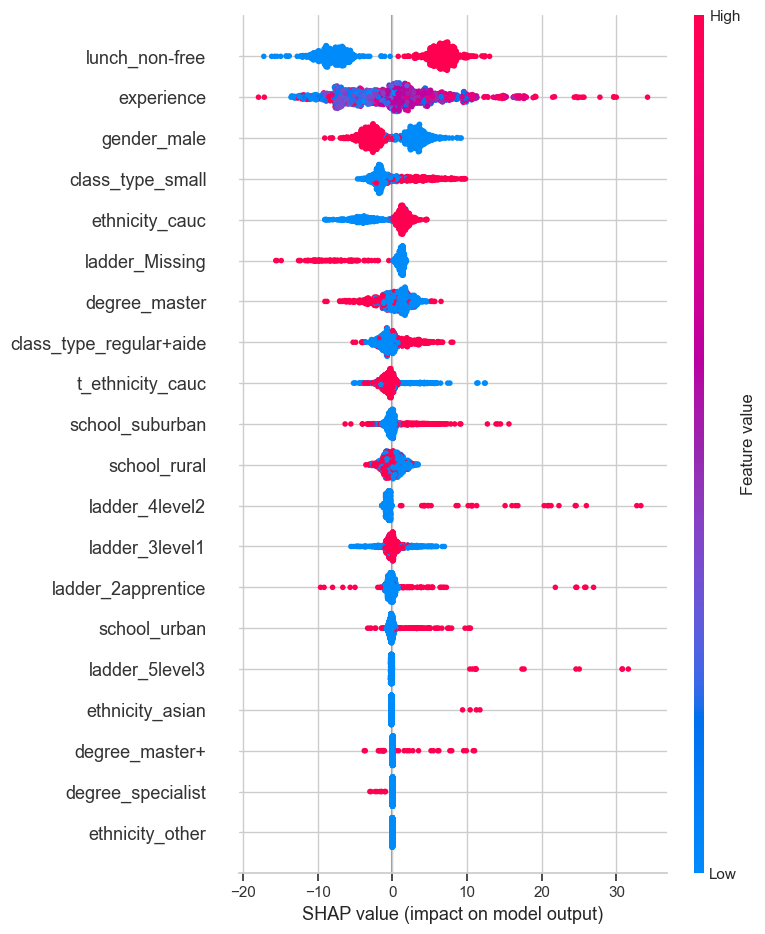

In [47]:
# SHAP analysis for xbg
# Convert boolean columns to numeric (int)
for col in X_test.columns:
   if X_test[col].dtype == 'bool':
       X_test[col] = X_test[col].astype(int)

explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, show=False)

This Shap summary plot takes 8 minutes to execute... here's the screenshot for the top features. Running the cell above on colab is computationaly and time-consuming. To prevent accidentally running that cell, we have commented out the cell.
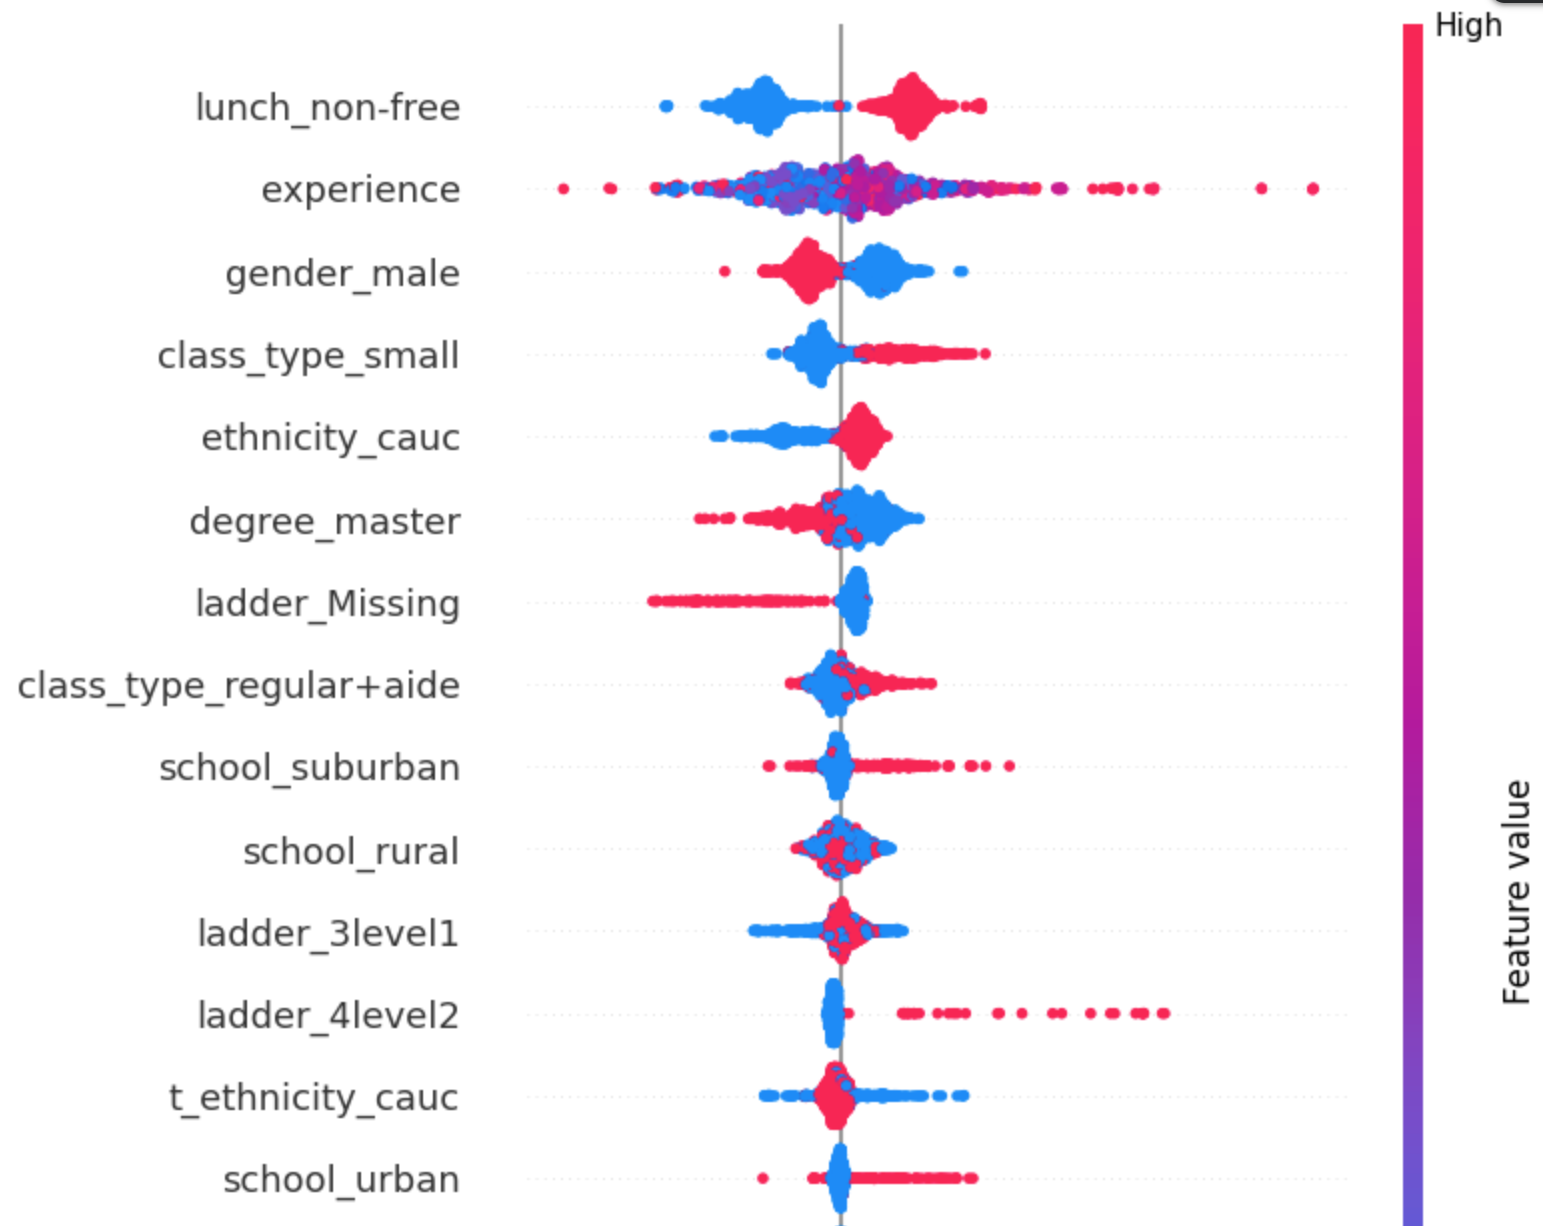

### Selected model (MSE_out)
Code for executing our selected model xgb_read with the out-of-sample 'db_out' MSE

In [48]:
def data_cleaner_out(df):
    df = df.copy()

    # Drop unnecessary columns
    df = df.drop(["birth", "schooldistrict_id", "school_id"], axis=1)

    # Only fill ladder missing (categorical missing would otherwise create ambiguity)
    ladder_map = {
        "probation": "1probation",
        "apprentice": "2apprentice",
        "level1": "3level1",
        "level2": "4level2",
        "level3": "5level3"
    }

    df["ladder"] = df["ladder"].replace(ladder_map)
    df["ladder"] = df["ladder"].fillna("Missing")
    df["experience"] = df["experience"].fillna(df["experience"].mean())

    df["score_read"] = df["score_read"].fillna(df["score_read"].mean())
    df["score_math"] = df["score_math"].fillna(df["score_math"].mean())

    # Create dummies (including NaN categories)
    df = pd.get_dummies(df, dummy_na=True, drop_first=True)

    
    # Drop all dummy columns representing NaN categories
    # These are named like: variable_nan or variable_NaN
    df = df[[col for col in df.columns if not col.endswith("_nan") and not col.endswith("_NaN")]]

    return df


In [49]:
# Prepare and cleaned db_out data
cleaned_db_out = data_cleaner_out(db_out)
read_y = cleaned_db_out["score_read"]
math_y = cleaned_db_out["score_math"]
cleaned_db_out = cleaned_db_out.drop(["score_read","score_math"], axis=1)

cleaned_db_out

,experience,gender_male,lunch_non-free,ethnicity_amindian,ethnicity_asian,ethnicity_cauc,ethnicity_hispanic,ethnicity_other,class_type_regular+aide,class_type_small,...,school_urban,degree_master,degree_master+,degree_specialist,ladder_2apprentice,ladder_3level1,ladder_4level2,ladder_5level3,ladder_Missing,t_ethnicity_cauc
0,6.0,True,False,False,False,True,False,False,False,True,...,False,True,False,False,False,True,False,False,False,True
1,1.0,True,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,True
2,5.0,True,True,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,11.0,False,False,False,False,True,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
4,2.0,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5055,8.0,False,False,False,False,True,False,False,False,True,...,False,True,False,False,False,True,False,False,False,True
5056,17.0,True,True,False,False,True,False,False,False,True,...,True,True,False,False,False,True,False,False,False,True
5057,15.0,False,True,False,False,True,False,False,False,False,...,False,True,False,False,False,True,False,False,False,True
5058,11.0,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,True,False,False,False,True


In [50]:
xgb_read_out = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
xgb_read_out.fit(X=X, y=y)


,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [51]:
read_out = xgb_read_out.predict(cleaned_db_out)

read_mse_out = mean_squared_error(read_y, read_out)

## Modeling of score_math

### OLS for score_math

In [55]:
# Drop missing values of score_math
db_math = cleaned_data.dropna(subset=['score_math'])

# MAke dammu vars
db_math=pd.get_dummies(db_math, drop_first=True)
db_math.rename(columns={'lunch_non-free': 'lunch_nonfree'}, inplace=True)
db_math.rename(columns={'class_type_regular+aide': 'class_type_regular_aide'}, inplace=True)
db_math.rename(columns={'degree_master+': 'degree_masterplus'}, inplace=True)
db_math.describe(include="all")

,score_read,score_math,experience,gender_male,lunch_nonfree,ethnicity_amindian,ethnicity_asian,ethnicity_cauc,ethnicity_hispanic,ethnicity_other,...,school_urban,degree_master,degree_masterplus,degree_specialist,ladder_2apprentice,ladder_3level1,ladder_4level2,ladder_5level3,ladder_Missing,t_ethnicity_cauc
count,4590.000000,4656.000000,4656.000000,4656,4656,4656,4656,4656,4656,4656,...,4656,4656,4656,4656,4656,4656,4656,4656,4656,4656
unique,NaN,NaN,NaN,2,2,2,2,2,2,2,...,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,True,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
freq,NaN,NaN,NaN,2386,2390,4654,4645,3119,4652,4651,...,4254,3174,4543,4626,4266,3460,4566,4615,4210,3924
mean,436.354031,485.214347,9.289734,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,31.451997,47.737980,5.855403,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,346.000000,288.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,414.000000,454.000000,5.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,433.000000,481.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,453.000000,513.000000,13.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [56]:
db_math

,score_read,score_math,experience,gender_male,lunch_nonfree,ethnicity_amindian,ethnicity_asian,ethnicity_cauc,ethnicity_hispanic,ethnicity_other,...,school_urban,degree_master,degree_masterplus,degree_specialist,ladder_2apprentice,ladder_3level1,ladder_4level2,ladder_5level3,ladder_Missing,t_ethnicity_cauc
0,474.0,602.0,6.0,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
1,403.0,434.0,1.0,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
2,455.0,520.0,5.0,True,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
3,405.0,454.0,11.0,False,False,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
4,433.0,473.0,2.0,False,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5053,393.0,405.0,12.0,True,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
5055,434.0,520.0,8.0,False,False,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
5056,470.0,576.0,17.0,True,True,False,False,True,False,False,...,True,True,False,False,False,True,False,False,False,True
5057,474.0,626.0,15.0,False,True,False,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True


In [57]:
selected_cols = ['experience', 'gender_male', 'lunch_nonfree', 'school_urban','school_suburban','school_rural',
                 'degree_master','degree_masterplus', 'degree_specialist','ladder_2apprentice','ladder_3level1',
                 'ladder_4level2','ladder_5level3','t_ethnicity_cauc','class_type_small']
interactions = create_interactions(db_math,selected_cols)
interactions = interactions.drop(columns=[col for col in interactions.columns if col in db_math.columns])
db_math = pd.concat([db_math, interactions], axis=1)
db_math = db_math.drop(columns='score_read')



/var/folders/nt/zkjhlc4x0p93xgt6ffs208t40000gn/T/ipykernel_71219/1914187752.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  interaction_df[interaction_name] = df[col1] * df[col2]
/var/folders/nt/zkjhlc4x0p93xgt6ffs208t40000gn/T/ipykernel_71219/1914187752.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  interaction_df[interaction_name] = df[col1] * df[col2]
/var/folders/nt/zkjhlc4x0p93xgt6ffs208t40000gn/T/ipykernel_71219/1914187752.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of 

In [58]:
# Define X and y
X = db_math.drop(columns=['score_math'])
y = db_math['score_math']

In [59]:
formula = f'score_math ~ {" + ".join(X.columns)}'
print(formula)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit OLS model full
OLSmodel = ols(formula, data=pd.concat([X_train, y_train], axis=1)).fit()

# Predict and evaluate
y_pred = OLSmodel.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

# Print summary and MSE
print(OLSmodel.summary())
print(f"MSE: {mse}")

score_math ~ experience + gender_male + lunch_nonfree + ethnicity_amindian + ethnicity_asian + ethnicity_cauc + ethnicity_hispanic + ethnicity_other + class_type_regular_aide + class_type_small + school_rural + school_suburban + school_urban + degree_master + degree_masterplus + degree_specialist + ladder_2apprentice + ladder_3level1 + ladder_4level2 + ladder_5level3 + ladder_Missing + t_ethnicity_cauc + experience_x_gender_male + experience_x_lunch_nonfree + experience_x_school_urban + experience_x_school_suburban + experience_x_school_rural + experience_x_degree_master + experience_x_degree_masterplus + experience_x_degree_specialist + experience_x_ladder_2apprentice + experience_x_ladder_3level1 + experience_x_ladder_4level2 + experience_x_ladder_5level3 + experience_x_t_ethnicity_cauc + experience_x_class_type_small + gender_male_x_lunch_nonfree + gender_male_x_school_urban + gender_male_x_school_suburban + gender_male_x_school_rural + gender_male_x_degree_master + gender_male_x_de

### LASSO, Ridge, and ElasticNet

In [60]:
# Lasso for score_math
train, test = train_test_split(db_math, test_size = 0.3,random_state=1)
response = 'score_math'
numerical_predictors = ['experience','experience_x_gender_male','experience_x_lunch_nonfree','experience_x_school_urban',
                        'experience_x_school_suburban','experience_x_school_rural','experience_x_degree_master',
                        'experience_x_degree_masterplus','experience_x_degree_specialist','experience_x_ladder_2apprentice',
                        'experience_x_ladder_3level1','experience_x_ladder_4level2','experience_x_ladder_5level3',
                        'experience_x_t_ethnicity_cauc']
predictors = [x for x in db_math.columns if x not in response] # the list of all predictors

In [61]:
mu = train[numerical_predictors].mean() # mean for each feature
sigma = train[numerical_predictors].std() # std for each feature

In [62]:
train_std = train.copy()
test_std = test.copy()
train_std[numerical_predictors] = (train[numerical_predictors] - mu) / sigma
test_std[numerical_predictors] = (test[numerical_predictors] - mu) / sigma

train_std[numerical_predictors].mean()
train_std[numerical_predictors].std()

experience                         1.0
experience_x_gender_male           1.0
experience_x_lunch_nonfree         1.0
experience_x_school_urban          1.0
experience_x_school_suburban       1.0
experience_x_school_rural          1.0
experience_x_degree_master         1.0
experience_x_degree_masterplus     1.0
experience_x_degree_specialist     1.0
experience_x_ladder_2apprentice    1.0
experience_x_ladder_3level1        1.0
experience_x_ladder_4level2        1.0
experience_x_ladder_5level3        1.0
experience_x_t_ethnicity_cauc      1.0
dtype: float64

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

alphas = np.logspace(-3, 2, 100)
lasso_cv = LassoCV(alphas=alphas,cv = 5) #5-fold CV - returns optimal lambda as part of the process
lasso_cv.fit(train_std[predictors],train_std[response])
print(f'LASSO Lambda: {lasso_cv.alpha_}')
# Lasso MSE
y_pred_test = lasso_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")



LASSO Lambda: 0.02595024211399736
Test R²:  0.1442
Test MSE:  1886.75


### Ridge

In [64]:
from sklearn.linear_model import RidgeCV

alphas = np.logspace(-3, 2, 100) # grid is on log scale 100 values from 10^-3 to 10^2
ridge_cv = RidgeCV(alphas=alphas, cv = 5)
ridge_cv.fit(train_std[predictors], train_std[response])
print(f'Ridge Lambda: {ridge_cv.alpha_}')
# Ridge mse
y_pred_test = ridge_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")


Ridge Lambda: 4.328761281083057
Test R²:  0.1441
Test MSE:  1887.19


### ElasticNet

In [65]:
from sklearn.linear_model import ElasticNetCV
l1_ratio_grid = [0.001, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.99, 1]
alphas = np.logspace(-3, 2, 100)
enet_cv = ElasticNetCV(alphas=alphas,l1_ratio = l1_ratio_grid, cv = 5, random_state=1)
enet_cv.fit(train_std[predictors],train_std[response])
print(f'ElasticNet Lambda: {enet_cv.alpha_} l1_ratio: {enet_cv.l1_ratio_}')
# Elsaticnet mse
y_pred_test = enet_cv.predict(test_std[predictors])

print(f"Test R²:  {r2_score(test_std[response], y_pred_test):.4f}")
print(f"Test MSE:  {mean_squared_error(test_std[response], y_pred_test):.2f}")

/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.020e+02, tolerance: 6.008e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.092e+02, tolerance: 6.008e+02
  model = cd_fast.enet_coordinate_descent_gram(
/Users/gahan/Developer/data-science/machine-learning/econ3203/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:681: ConvergenceWarning: Objective di

ElasticNet Lambda: 0.001788649529057435 l1_ratio: 0.1
Test R²:  0.1445
Test MSE:  1886.20


Elasticnet suggests we use L1_ratio of 0.99, mostly Lasso with a lambda near that that from optimal lasso lambda

In [66]:
# Summarize of OLS,lasso,ridge,elasticnet for score_math
columns = ['R-squared', 'Test MSE']
rows = ['OLS','Ridge','LASSO','Elastic Net']

results = pd.DataFrame(0.0, columns=columns, index=rows) # initialising a dataframe to hold the results

methods = [OLSmodel, ridge_cv, lasso_cv, enet_cv]
test_data = [X_test, test_std[predictors], test_std[predictors], test_std[predictors]] # Use scaled data for sklearn models

for row, method, test_X in zip(rows, methods, test_data):
    if row == 'OLS':
        # For OLS, predict directly and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(y_test, y_pred)
        mse = mean_squared_error(y_test, y_pred)
    else:
        # For scikit-learn models, predict from the scaled test data and calculate metrics
        y_pred = method.predict(test_X)
        r2 = r2_score(test_std[response], y_pred)
        mse = mean_squared_error(test_std[response], y_pred)

    results.loc[row, 'R-squared'] = r2
    results.loc[row, 'Test MSE'] = mse

results.round(3)

,R-squared,Test MSE
OLS,0.145,2105.262
Ridge,0.144,1887.187
LASSO,0.144,1886.753
Elastic Net,0.144,1886.197


### XGBoost with Interactions

In [67]:
import xgboost as xgb
import shap

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 5,
    'min_child_weight':8,
    'learning_rate':0.1,
    'subsample': 1.0,
    'colsample_bytree': 1.0
}
model_xg = xgb.XGBRegressor(early_stopping_rounds=10,
                            verbosity=0,
                            **params)
model_xg.fit(X_train, y_train,
             eval_set=[(X_test, y_test)],
             verbose=False)

y_pred_train = model_xg.predict(X_train)
y_pred_test = model_xg.predict(X_test)

print(f"\nTrain R²: {r2_score(y_train, y_pred_train):.4f}")
print(f"Test R²:  {r2_score(y_test, y_pred_test):.4f}")
print(f"Train MSE: {mean_squared_error(y_train, y_pred_train):.2f}")
print(f"Test MSE:  {mean_squared_error(y_test, y_pred_test):.2f}")


Train R²: 0.3188
Test R²:  0.1958
Train MSE: 1520.19
Test MSE:  1980.17


### Tree regression without Interaction terms

In [68]:
# Train tree models without interaction terms
# Create dummy vars
math = pd.get_dummies(math, drop_first=True)

# For cv test (require full data)
X = math.drop(columns=[response])
y = math[response]

train, test = train_test_split(math, test_size = 0.3,random_state=1)
response = 'score_math'
X_train = train.drop(columns=[response])
y_train = train[response]

X_test = test.drop(columns=[response])
y_test = test[response]


#### Random Forest

In [69]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Define a metrics function
def metrics(X_test, y_test, model):
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    return r2, mse

rf = RandomForestRegressor(n_estimators=1000, max_features ='sqrt', min_samples_leaf=3, random_state=1)
rf.fit(X_train, y_train)
ypred_rf = rf.predict(X_test)
# Scores result
r2_rf, mse_rf = metrics(X_test, y_test, rf)

print(f"Test R²:   {r2_rf}")
print(f"Test MSE:  {mse_rf}")

Test R²:   0.19645320514285014
Test MSE:  1771.650156208102


Woah, so much better than lasso and models above

In [70]:
rf = RandomForestRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [5,6, 7],
    'max_features': ['sqrt', 'log2'],
    "min_samples_leaf": [2,3,4]
    }

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(rf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/opt/homebrew/Cellar/python@3.13/3.13.7/Frameworks/Python.framework/Versions/3.13/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See http

{'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 2}


In [71]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = RandomForestRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")

results.loc['rf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]

Fold 1: R² = 0.1469, MSE = 1900.4225
Fold 2: R² = 0.1718, MSE = 1923.4985
Fold 3: R² = 0.1741, MSE = 1896.0136
Fold 4: R² = 0.1540, MSE = 1907.4684
Fold 5: R² = 0.1305, MSE = 1988.7494

Mean R²: 0.1555
Mean MSE: 1923.2305


I guess the rf is overfitting, and once try 5 cv K-folds, the performance is worse. But why is it so much better earlier?? Hyperparameter range is not the optimal range?

#### Gradient Boost

In [72]:
from sklearn.ensemble import GradientBoostingRegressor

gbf = GradientBoostingRegressor(n_estimators=1000, n_iter_no_change=50, learning_rate=0.1,
                                subsample=0.9, max_depth=3, random_state=1)
gbf.fit(X_train, y_train)
ypred_gbf = gbf.predict(X_test)
r2_gbf, mse_gbf = metrics(X_test, y_test, gbf)
print(f"Test R²:   {r2_gbf}")
print(f"Test MSE:  {mse_gbf}")


Test R²:   0.19111230499968201
Test MSE:  1783.425707592907


In [73]:

gbf = GradientBoostingRegressor(n_estimators=1000, random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.07, 0.09,0.1],
    "subsample": [0.8, 0.9]
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(gbf, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)


{'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.9}


In [74]:
# See the r-score and mse for the cv=5 best_params of gbf
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = GradientBoostingRegressor(n_estimators=1000,
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['gbf_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


Fold 1: R² = 0.1848, MSE = 1815.9362
Fold 2: R² = 0.2457, MSE = 1751.9420
Fold 3: R² = 0.2206, MSE = 1789.2762
Fold 4: R² = 0.2373, MSE = 1719.7868
Fold 5: R² = 0.1760, MSE = 1884.8024

Mean R²: 0.2129
Mean MSE: 1792.3487


#### XgBoost

In [75]:
# Xgboost with no interaction terms
params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'min_child_weight':4,
    'learning_rate':0.02,
    'subsample': 0.4,
    'colsample_bytree': 0.6
}
xgb_math = xgb.XGBRegressor(n_estimators=1000,
                            verbosity=0,
                            **params,
                            random_state=1)
xgb_math.fit(X_train, y_train,
             verbose=False)
predictions = xgb_math.predict(X_test)
# Predict and evaluate
y_pred = xgb_math.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
#r2_xgb, mse_xgb = metrics(X_test, y_test, xgb)
# Print summary and MSE
print(f"MSE: {mse}")

MSE: 1775.9742886738889


In [76]:
from sklearn.model_selection import GridSearchCV, KFold
from xgboost import XGBRegressor

xgb_math = XGBRegressor(n_estimators=1000, objective="reg:squarederror", random_state=1)

# Define a smaller parameter grid for demonstration
param_grid = {
    "max_depth": [4,5, 6],
    'min_child_weight':[4,5],
    "learning_rate": [0.02, 0.04, 0.05,0.06],
    "subsample": [0.6, 0.7],
    "colsample_bytree": [0.5, 0.6],
}

cv = KFold(n_splits=5, shuffle=True, random_state=1)
search = GridSearchCV(xgb_math, param_grid, cv=cv, scoring="neg_mean_squared_error", n_jobs=-1,)
search.fit(X_train, y_train)

best_params = search.best_params_
print(best_params)

{'colsample_bytree': 0.5, 'learning_rate': 0.02, 'max_depth': 6, 'min_child_weight': 5, 'subsample': 0.7}


In [77]:
# See the r-score and mse for the cv=5 best_params
r2_scores = []
mse_scores = []

for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    model = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    mse = mean_squared_error(y_te, y_pred)

    r2_scores.append(r2)
    mse_scores.append(mse)

    print(f"Fold {fold+1}: R² = {r2:.4f}, MSE = {mse:.4f}")

# Print mean scores
print(f"\nMean R²: {np.mean(r2_scores):.4f}")
print(f"Mean MSE: {np.mean(mse_scores):.4f}")
results.loc['xgb_cv'] = [np.mean(r2_scores), np.mean(mse_scores)]


Fold 1: R² = 0.1960, MSE = 1791.0348
Fold 2: R² = 0.2525, MSE = 1736.1355
Fold 3: R² = 0.2386, MSE = 1747.8474
Fold 4: R² = 0.2383, MSE = 1717.3423
Fold 5: R² = 0.1830, MSE = 1868.6953

Mean R²: 0.2217
Mean MSE: 1772.2110


In [78]:
# Show comparison result
results.round(3)

,R-squared,Test MSE
OLS,0.145,2105.262
Ridge,0.144,1887.187
LASSO,0.144,1886.753
Elastic Net,0.144,1886.197
rf_cv,0.155,1923.230
gbf_cv,0.213,1792.349
xgb_cv,0.222,1772.211


PermutationExplainer explainer: 1398it [00:38, 26.71it/s]                          
/var/folders/nt/zkjhlc4x0p93xgt6ffs208t40000gn/T/ipykernel_71219/976456448.py:11: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test, show=False)


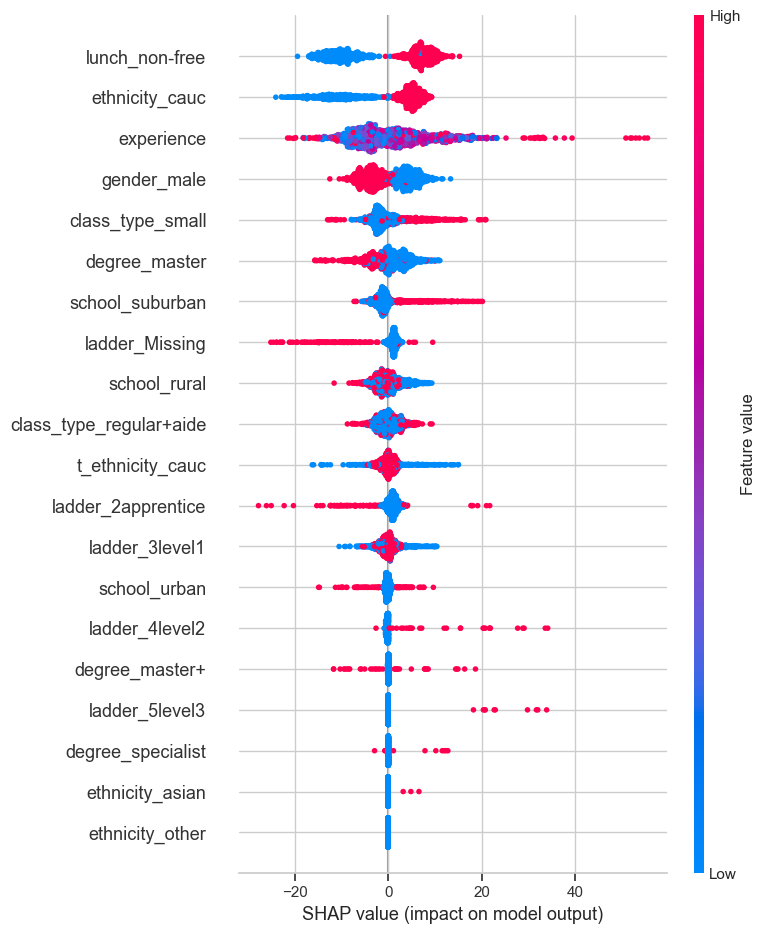

In [81]:
# SHAP analysis
# Convert boolean columns to numeric (int)
for col in X_test.columns:
   if X_test[col].dtype == 'bool':
       X_test[col] = X_test[col].astype(int)

explainer = shap.Explainer(model.predict, X_test)
shap_values = explainer(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, show=False)

Takes alot of time to run ...so here's a screenshot of the output! Just. like before the cell itself has been commented out.


[image.png](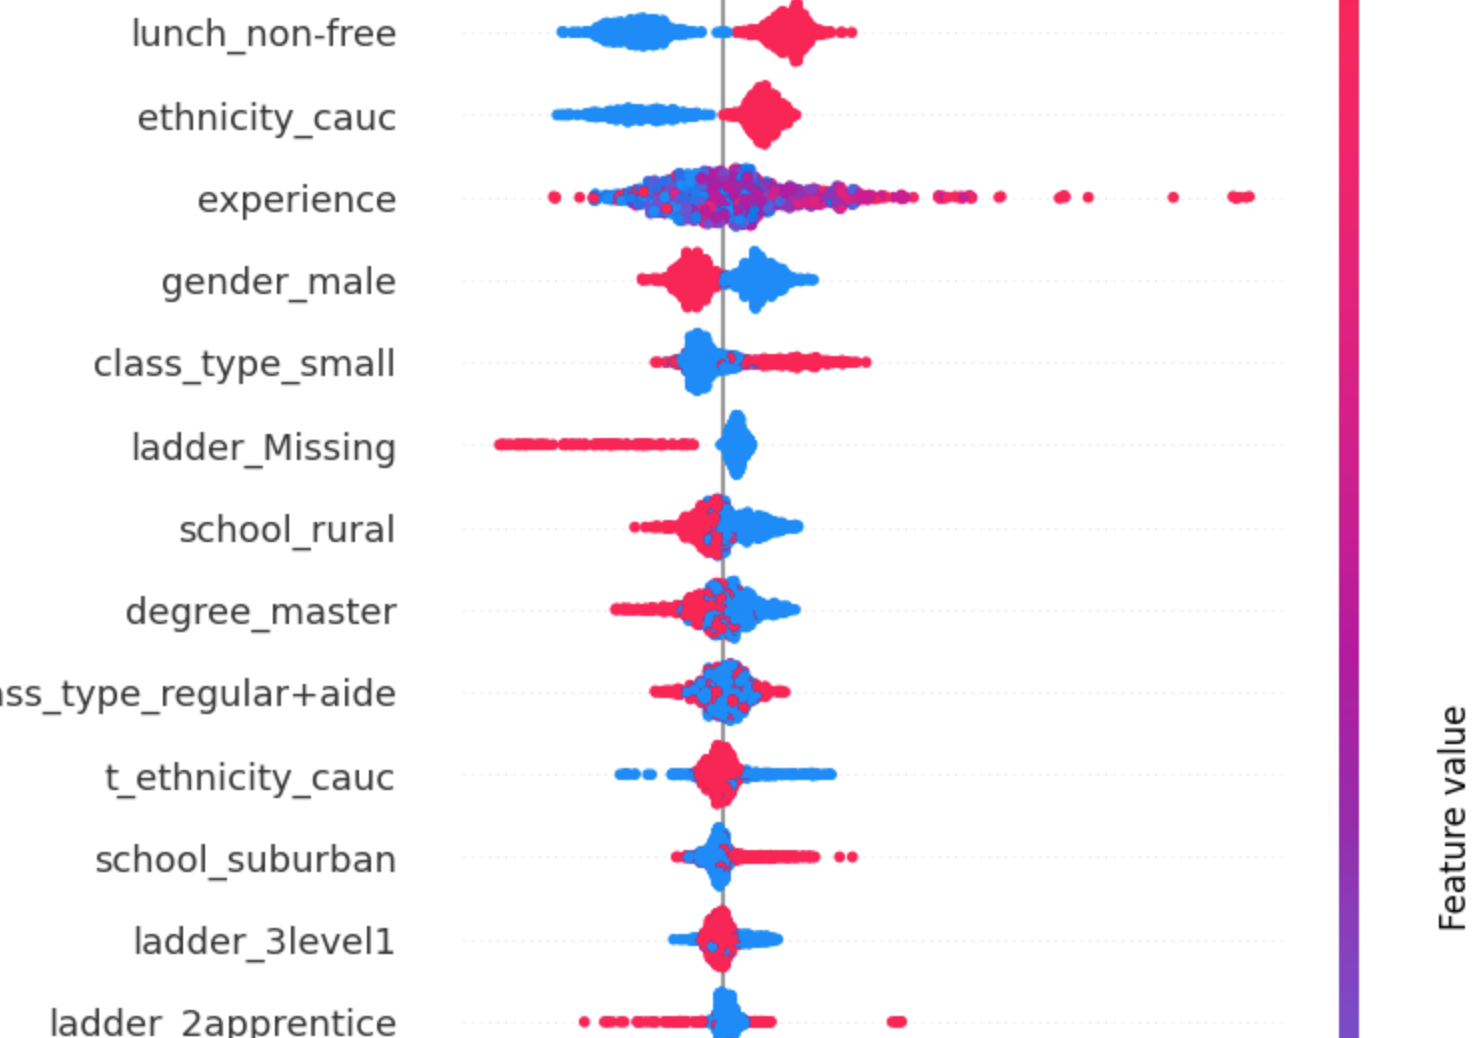)

Code to execute mse_out for db_out for our selected model xgb_math

### Selected model (MSE_out)
Code to executing the mse_out for socre_math

In [ ]:
xgb_math_out = XGBRegressor(n_estimators=1000,
                         objective="reg:squarederror",
                         random_state=1,
                         **best_params)

xgb_math_out.fit(X=X, y=y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.5
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
math_out = xgb_math_out.predict(cleaned_db_out)

math_mse_out = mean_squared_error(math_y, math_out)



1399.9991262674305

## Total MSE
Output the total of mse_out for score_read and score_math

In [ ]:
total_mse = (1/2) * (math_mse_out + read_mse_out)
print(f"Total MSE: {total_mse:.4f}")

Total MSE: 1016.9213
